# Task 2: Sequence Deep Learning Fraud Detection with GRU

**Student:** Swastika Adhikari

**Project:** Hybrid Machine Learning, Deep Learning, and Graph Neural Network Framework for Financial Fraud Detection

## 2. Setup and Reproducibility

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Import libraries
import os
import random
import copy
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

In [ ]:
# Reproducibility Configuration
RANDOM_SEED = 42

def configure_reproducibility(seed=42):
    """
    Set all random seeds for reproducible results across runs.
    Critical for fair comparison between variations.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

configure_reproducibility(RANDOM_SEED)

# Device Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 70)
print("ENVIRONMENT INFORMATION")
print("=" * 70)
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Device: {torch.cuda.get_device_name(0)}")
print(f"Computing Device: {device}")
print(f"Random Seed: {RANDOM_SEED}")
print("=" * 70)

ENVIRONMENT INFORMATION
PyTorch Version: 2.9.0+cpu
CUDA Available: False
Computing Device: cpu
Random Seed: 42


## 3. Data Loading and Exploration

In [ ]:
DATA_FILEPATH = "/content/drive/MyDrive/Dataset/PS_20174392719_1491204439457_log.csv"


if not os.path.exists(DATA_FILEPATH):
    raise FileNotFoundError(f"Dataset not found at: {DATA_FILEPATH}")

transactions_df = pd.read_csv(DATA_FILEPATH)

print("\n" + "=" * 70)
print("DATASET OVERVIEW")
print("=" * 70)
print(f"Total Transactions: {transactions_df.shape[0]:,}")
print(f"Number of Features: {transactions_df.shape[1]}")
print(f"Fraud Rate: {transactions_df['isFraud'].mean() * 100:.4f}%")
print("=" * 70)


DATASET OVERVIEW
Total Transactions: 6,362,620
Number of Features: 11
Fraud Rate: 0.1291%


In [ ]:
print("\n" + "=" * 70)
print("DATA QUALITY ASSESSMENT")
print("=" * 70)

# Check for missing values
missing_values = transactions_df.isna().sum()
if missing_values.sum() == 0:
    print("No missing values detected")
else:
    print("Missing values by column:")
    print(missing_values[missing_values > 0])

print("\nFraud Label Distribution:")
print(transactions_df['isFraud'].value_counts())
print("\nTransaction Type Distribution:")
print(transactions_df['type'].value_counts())
print("=" * 70)


DATA QUALITY ASSESSMENT
No missing values detected

Fraud Label Distribution:
isFraud
0    6354407
1       8213
Name: count, dtype: int64

Transaction Type Distribution:
type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64


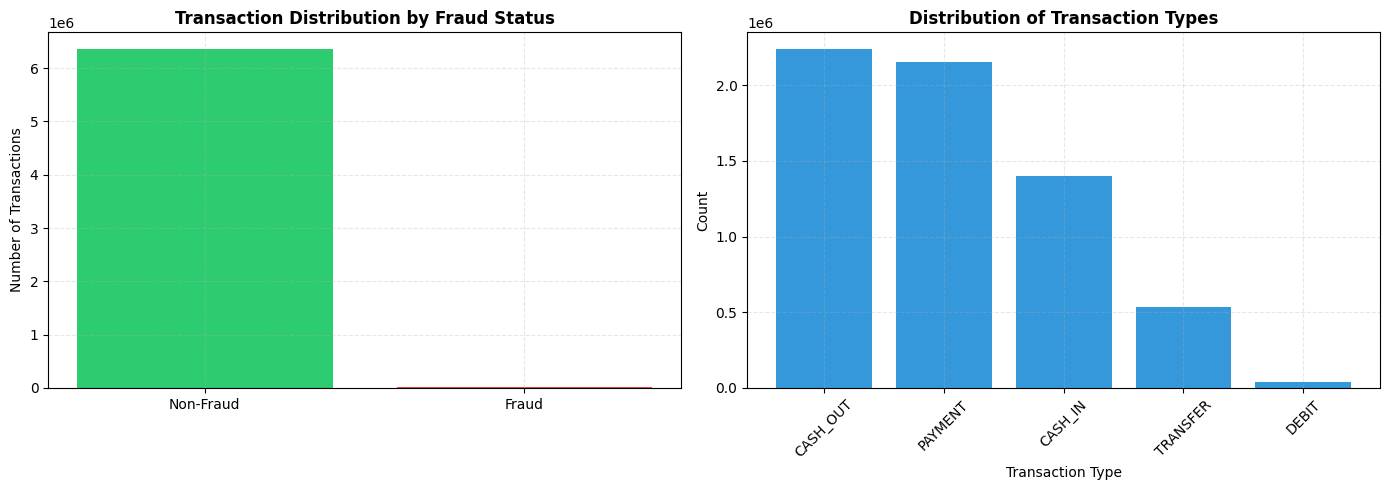

In [ ]:
# Data Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Fraud vs Non-Fraud
fraud_counts = transactions_df['isFraud'].value_counts()
axes[0].bar(['Non-Fraud', 'Fraud'], fraud_counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Transaction Distribution by Fraud Status', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Transactions', fontsize=10)
axes[0].grid(True, alpha=0.3, linestyle='--')

# Plot 2: Transaction Types
transaction_types = transactions_df['type'].value_counts()
axes[1].bar(transaction_types.index, transaction_types.values, color='#3498db')
axes[1].set_title('Distribution of Transaction Types', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Transaction Type', fontsize=10)
axes[1].set_ylabel('Count', fontsize=10)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

## 4. Preprocessing

### Account-Based Data Splitting

We use a leakage-safe account-based split to ensure no account appears in multiple sets. This prevents data leakage and provides realistic evaluation where the model must generalize to completely unseen accounts.

In [ ]:
random_generator = np.random.default_rng(RANDOM_SEED)

# Aggregate fraud status by account
account_fraud_status = (
    transactions_df
    .groupby('nameOrig', sort=False)['isFraud']
    .max()
    .reset_index()
)

# Separate fraudulent and normal accounts
fraudulent_accounts = account_fraud_status.loc[
    account_fraud_status['isFraud'] == 1, 'nameOrig'
].values

normal_accounts = account_fraud_status.loc[
    account_fraud_status['isFraud'] == 0, 'nameOrig'
].values

# Shuffle accounts
random_generator.shuffle(fraudulent_accounts)
random_generator.shuffle(normal_accounts)

# Limit dataset size for computational efficiency
MAX_FRAUD_ACCOUNTS = 50000
MAX_NORMAL_ACCOUNTS = 600000

fraudulent_accounts = fraudulent_accounts[:min(len(fraudulent_accounts), MAX_FRAUD_ACCOUNTS)]
normal_accounts = normal_accounts[:min(len(normal_accounts), MAX_NORMAL_ACCOUNTS)]

In [ ]:
def split_accounts_into_sets(account_list, train_proportion=0.6, validation_proportion=0.2):
    """
    Split accounts into train, validation, and test sets.

    Parameters:
    - account_list: array of account IDs
    - train_proportion: fraction for training set
    - validation_proportion: fraction for validation set

    Returns:
    - train, validation, test account arrays
    """
    total_accounts = len(account_list)
    num_train = int(train_proportion * total_accounts)
    num_validation = int(validation_proportion * total_accounts)

    train_accounts = account_list[:num_train]
    validation_accounts = account_list[num_train:num_train + num_validation]
    test_accounts = account_list[num_train + num_validation:]

    return train_accounts, validation_accounts, test_accounts


# Split fraudulent accounts
fraud_train_accts, fraud_val_accts, fraud_test_accts = split_accounts_into_sets(fraudulent_accounts)

# Split normal accounts
normal_train_accts, normal_val_accts, normal_test_accts = split_accounts_into_sets(normal_accounts)

# Balance validation and test sets
VALIDATION_NORMAL_TARGET = 10000
TEST_NORMAL_TARGET = 20000

normal_val_accts = normal_val_accts[:VALIDATION_NORMAL_TARGET]
normal_test_accts = normal_test_accts[:TEST_NORMAL_TARGET]

# Combine fraud and normal accounts for each set
train_account_ids = np.concatenate([fraud_train_accts, normal_train_accts])
validation_account_ids = np.concatenate([fraud_val_accts, normal_val_accts])
test_account_ids = np.concatenate([fraud_test_accts, normal_test_accts])

# Shuffle combined sets
random_generator.shuffle(train_account_ids)
random_generator.shuffle(validation_account_ids)
random_generator.shuffle(test_account_ids)

# Verify no overlap between sets
assert set(train_account_ids).isdisjoint(validation_account_ids), "Train-Val overlap detected!"
assert set(train_account_ids).isdisjoint(test_account_ids), "Train-Test overlap detected!"
assert set(validation_account_ids).isdisjoint(test_account_ids), "Val-Test overlap detected!"

# Create data splits
train_transactions = transactions_df[transactions_df['nameOrig'].isin(train_account_ids)].copy()
validation_transactions = transactions_df[transactions_df['nameOrig'].isin(validation_account_ids)].copy()
test_transactions = transactions_df[transactions_df['nameOrig'].isin(test_account_ids)].copy()

print("\n" + "=" * 70)
print("ACCOUNT-BASED SPLIT SUMMARY")
print("=" * 70)
print(f"Training Set:")
print(f"  Accounts: {len(train_account_ids):,}")
print(f"  Transactions: {len(train_transactions):,}")
print(f"  Fraud Rate: {train_transactions['isFraud'].mean() * 100:.4f}%")

print(f"\nValidation Set:")
print(f"  Accounts: {len(validation_account_ids):,}")
print(f"  Transactions: {len(validation_transactions):,}")
print(f"  Fraud Rate: {validation_transactions['isFraud'].mean() * 100:.4f}%")

print(f"\nTest Set:")
print(f"  Accounts: {len(test_account_ids):,}")
print(f"  Transactions: {len(test_transactions):,}")
print(f"  Fraud Rate: {test_transactions['isFraud'].mean() * 100:.4f}%")
print("=" * 70)


ACCOUNT-BASED SPLIT SUMMARY
Training Set:
  Accounts: 364,927
  Transactions: 365,483
  Fraud Rate: 1.3481%

Validation Set:
  Accounts: 11,642
  Transactions: 11,659
  Fraud Rate: 14.0835%

Test Set:
  Accounts: 21,644
  Transactions: 21,676
  Fraud Rate: 7.5844%


### Transaction Type Encoding

In [ ]:
# Build encoding from training data
unique_transaction_types = sorted(train_transactions['type'].unique())
transaction_type_mapping = {trans_type: idx + 1 for idx, trans_type in enumerate(unique_transaction_types)}

# Apply encoding
train_transactions['type_id'] = train_transactions['type'].map(transaction_type_mapping).astype(np.int64)
validation_transactions['type_id'] = validation_transactions['type'].map(transaction_type_mapping).fillna(0).astype(np.int64)
test_transactions['type_id'] = test_transactions['type'].map(transaction_type_mapping).fillna(0).astype(np.int64)

NUM_TRANSACTION_TYPES = len(transaction_type_mapping) + 1

print(f"\nTransaction type encoding: {transaction_type_mapping}")
print(f"Total transaction types (including padding): {NUM_TRANSACTION_TYPES}")


Transaction type encoding: {'CASH_IN': 1, 'CASH_OUT': 2, 'DEBIT': 3, 'PAYMENT': 4, 'TRANSFER': 5}
Total transaction types (including padding): 6


### Feature Engineering

In [ ]:
def create_engineered_features(dataframe):
    """
    Create additional features from raw transaction data.

    Features created:
    - log_amount: Log-transformed transaction amount
    - oldbalanceOrg_log: Log-transformed origin balance
    - oldbalanceDest_log: Log-transformed destination balance
    - amount_over_oldorig: Transaction amount relative to origin balance
    - amount_over_olddest: Transaction amount relative to destination balance
    - orig_balance_is_zero: Binary flag for zero origin balance
    - dest_balance_is_zero: Binary flag for zero destination balance
    """
    df = dataframe.copy()


    df['log_amount'] = np.log1p(df['amount']).astype(np.float32)
    df['oldbalanceOrg_log'] = np.log1p(df['oldbalanceOrg']).astype(np.float32)
    df['oldbalanceDest_log'] = np.log1p(df['oldbalanceDest']).astype(np.float32)


    df['amount_over_oldorig'] = (df['amount'] / (df['oldbalanceOrg'] + 1.0)).astype(np.float32)
    df['amount_over_olddest'] = (df['amount'] / (df['oldbalanceDest'] + 1.0)).astype(np.float32)


    df['orig_balance_is_zero'] = (df['oldbalanceOrg'] == 0).astype(np.float32)
    df['dest_balance_is_zero'] = (df['oldbalanceDest'] == 0).astype(np.float32)

    return df

train_transactions = create_engineered_features(train_transactions)
validation_transactions = create_engineered_features(validation_transactions)
test_transactions = create_engineered_features(test_transactions)


NUMERIC_FEATURE_COLUMNS = [
    'log_amount',
    'oldbalanceOrg_log',
    'oldbalanceDest_log',
    'amount_over_oldorig',
    'amount_over_olddest',
    'orig_balance_is_zero',
    'dest_balance_is_zero'
]

print(f"\nEngineered {len(NUMERIC_FEATURE_COLUMNS)} numeric features:")
for feature in NUMERIC_FEATURE_COLUMNS:
    print(f"  - {feature}")


Engineered 7 numeric features:
  - log_amount
  - oldbalanceOrg_log
  - oldbalanceDest_log
  - amount_over_oldorig
  - amount_over_olddest
  - orig_balance_is_zero
  - dest_balance_is_zero


### Feature Normalization

All normalization is fit on training data only to prevent leakage.

In [ ]:
# Fit scaler on training data only
numeric_feature_scaler = StandardScaler()
numeric_feature_scaler.fit(train_transactions[NUMERIC_FEATURE_COLUMNS].values.astype(np.float32))

# Compute time gap scaler (training data only)
train_time_gaps = []
for account_id, account_group in train_transactions.groupby('nameOrig', sort=False):
    sorted_group = account_group.sort_values('step')
    time_diff = sorted_group['step'].diff().fillna(0).values
    time_diff_clipped = np.clip(time_diff, 0, 168)  # Cap at 1 week
    log_time_diff = np.log1p(time_diff_clipped).astype(np.float32)
    train_time_gaps.append(log_time_diff)

train_time_gaps_array = np.concatenate(train_time_gaps).reshape(-1, 1)
time_gap_scaler = StandardScaler()
time_gap_scaler.fit(train_time_gaps_array)

print("\n" + "=" * 70)
print("FEATURE SCALING COMPLETED")
print("=" * 70)
print("Numeric features scaled using training data statistics")
print("Time gap features scaled using training data statistics")
print("=" * 70)


FEATURE SCALING COMPLETED
Numeric features scaled using training data statistics
Time gap features scaled using training data statistics


### Sequence Construction

Build sliding window sequences for each account. Each sequence represents a transaction history window ending at the current transaction.

In [ ]:
MAX_SEQUENCE_LENGTH = 10
MAX_WINDOWS_PER_ACCOUNT_TRAIN = 50
MAX_WINDOWS_PER_ACCOUNT_EVAL = 100


def build_transaction_sequences(dataframe, max_sequence_len=10, max_windows=None):
    """
    Build sequential transaction windows for each account.

    Each window contains:
    - type_ids: Transaction type encoding
    - numeric_features: Engineered numeric features
    - time_gaps: Time between consecutive transactions
    - label: Fraud indicator for the current transaction
    - sequence_length: Actual number of transactions in window

    Parameters:
    - dataframe: Transaction data
    - max_sequence_len: Maximum lookback window
    - max_windows: Maximum windows per account (for memory efficiency)

    Returns:
    - List of sequence dictionaries
    """
    all_sequences = []

    for account_id, account_transactions in dataframe.groupby('nameOrig', sort=False):
        # Sort by time
        sorted_transactions = account_transactions.sort_values('step').reset_index(drop=True)

        # Calculate time gaps
        time_differences = sorted_transactions['step'].diff().fillna(0).values
        time_differences_clipped = np.clip(time_differences, 0, 168)
        log_time_gaps = np.log1p(time_differences_clipped).astype(np.float32)

        account_windows = []

        # Create sliding windows
        for current_idx in range(len(sorted_transactions)):
            window_start = max(0, current_idx - max_sequence_len + 1)
            transaction_window = sorted_transactions.iloc[window_start:current_idx + 1]

            window_data = {
                'type_ids': transaction_window['type_id'].values.astype(np.int64),
                'numeric_features': transaction_window[NUMERIC_FEATURE_COLUMNS].values.astype(np.float32),
                'time_gaps': log_time_gaps[window_start:current_idx + 1],
                'label': int(sorted_transactions.loc[current_idx, 'isFraud']),
                'sequence_length': len(transaction_window)
            }

            account_windows.append(window_data)

        # Limit windows per account if specified
        if max_windows is not None and len(account_windows) > max_windows:
            fraud_windows = [w for w in account_windows if w['label'] == 1]
            normal_windows = [w for w in account_windows if w['label'] == 0]

            if len(fraud_windows) >= max_windows:
                account_windows = fraud_windows[:max_windows]
            else:
                remaining_slots = max_windows - len(fraud_windows)
                account_windows = fraud_windows + normal_windows[-remaining_slots:]

        all_sequences.extend(account_windows)

    return all_sequences


# Build sequences for all splits
train_sequences = build_transaction_sequences(
    train_transactions,
    MAX_SEQUENCE_LENGTH,
    MAX_WINDOWS_PER_ACCOUNT_TRAIN
)

validation_sequences = build_transaction_sequences(
    validation_transactions,
    MAX_SEQUENCE_LENGTH,
    MAX_WINDOWS_PER_ACCOUNT_EVAL
)

test_sequences = build_transaction_sequences(
    test_transactions,
    MAX_SEQUENCE_LENGTH,
    MAX_WINDOWS_PER_ACCOUNT_EVAL
)

print("\n" + "=" * 70)
print("SEQUENCE CONSTRUCTION COMPLETE")
print("=" * 70)
print(f"Training Sequences: {len(train_sequences):,}")
print(f"  Fraud sequences: {sum(s['label'] for s in train_sequences):,}")
print(f"\nValidation Sequences: {len(validation_sequences):,}")
print(f"  Fraud sequences: {sum(s['label'] for s in validation_sequences):,}")
print(f"\nTest Sequences: {len(test_sequences):,}")
print(f"  Fraud sequences: {sum(s['label'] for s in test_sequences):,}")
print("=" * 70)


SEQUENCE CONSTRUCTION COMPLETE
Training Sequences: 365,483
  Fraud sequences: 4,927

Validation Sequences: 11,659
  Fraud sequences: 1,642

Test Sequences: 21,676
  Fraud sequences: 1,644


In [ ]:
def normalize_sequence_features(sequences):
    """
    Apply standardization to numeric features and time gaps in sequences.
    Uses pre-fitted scalers from training data.
    """
    for sequence in sequences:
        sequence['numeric_features'] = numeric_feature_scaler.transform(
            sequence['numeric_features']
        ).astype(np.float32)

        sequence['time_gaps'] = time_gap_scaler.transform(
            sequence['time_gaps'].reshape(-1, 1)
        ).flatten().astype(np.float32)

# Apply normalization
normalize_sequence_features(train_sequences)
normalize_sequence_features(validation_sequences)
normalize_sequence_features(test_sequences)

print("\nAll sequences normalized using training data statistics")


All sequences normalized using training data statistics


### PyTorch Dataset and DataLoader

In [ ]:
class TransactionSequenceDataset(Dataset):
    """
    PyTorch Dataset for transaction sequences.
    """
    def __init__(self, sequences):
        self.sequences = sequences

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, index):
        sequence = self.sequences[index]
        return (
            torch.tensor(sequence['type_ids'], dtype=torch.long),
            torch.tensor(sequence['numeric_features'], dtype=torch.float32),
            torch.tensor(sequence['time_gaps'], dtype=torch.float32).unsqueeze(1),
            torch.tensor(float(sequence['label']), dtype=torch.float32),
            int(sequence['sequence_length'])
        )


def collate_sequences(batch):
    """
    Custom collate function to pad variable-length sequences.
    """
    type_ids_list, numeric_list, time_gaps_list, labels_list, lengths_list = zip(*batch)

    # Pad sequences
    type_ids_padded = pad_sequence(type_ids_list, batch_first=True, padding_value=0)
    numeric_padded = pad_sequence(numeric_list, batch_first=True, padding_value=0.0)
    time_gaps_padded = pad_sequence(time_gaps_list, batch_first=True, padding_value=0.0)

    # Stack labels and lengths
    labels_tensor = torch.stack(labels_list).float()
    lengths_tensor = torch.tensor(lengths_list, dtype=torch.long)

    return type_ids_padded, numeric_padded, time_gaps_padded, labels_tensor, lengths_tensor


# DataLoader configuration
BATCH_SIZE = 64
dataloader_generator = torch.Generator().manual_seed(RANDOM_SEED)

train_dataloader = DataLoader(
    TransactionSequenceDataset(train_sequences),
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_sequences,
    generator=dataloader_generator
)

validation_dataloader = DataLoader(
    TransactionSequenceDataset(validation_sequences),
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_sequences
)

test_dataloader = DataLoader(
    TransactionSequenceDataset(test_sequences),
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_sequences
)

print("\n" + "=" * 70)
print("DATALOADERS INITIALIZED")
print("=" * 70)
print(f"Training batches: {len(train_dataloader)}")
print(f"Validation batches: {len(validation_dataloader)}")
print(f"Test batches: {len(test_dataloader)}")
print(f"Batch size: {BATCH_SIZE}")
print("=" * 70)


DATALOADERS INITIALIZED
Training batches: 5711
Validation batches: 183
Test batches: 339
Batch size: 64


## 5. Model Definition

### GRU Architecture



In [ ]:
NUM_NUMERIC_FEATURES = len(NUMERIC_FEATURE_COLUMNS)
class GRUFraudDetector(nn.Module):
    def __init__(
        self,
        num_transaction_types,
        embedding_dim=8,
        gru_hidden_size=64,
        num_gru_layers=2,
        dropout_rate=0.3
    ):
        super(GRUFraudDetector, self).__init__()

        self.type_embedding = nn.Embedding(
            num_transaction_types,
            embedding_dim,
            padding_idx=0
        )

        gru_input_size = embedding_dim + NUM_NUMERIC_FEATURES + 1

        self.gru = nn.GRU(
            input_size=gru_input_size,
            hidden_size=gru_hidden_size,
            num_layers=num_gru_layers,
            batch_first=True,
            dropout=dropout_rate if num_gru_layers > 1 else 0.0
        )

        self.dropout = nn.Dropout(dropout_rate)
        self.output_layer = nn.Linear(gru_hidden_size, 1)

    def forward(self, type_ids, numeric_features, time_gaps, sequence_lengths):
        type_embeddings = self.type_embedding(type_ids)
        combined_features = torch.cat([type_embeddings, numeric_features, time_gaps], dim=2)

        packed_sequences = nn.utils.rnn.pack_padded_sequence(
            combined_features,
            sequence_lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        _, h_n = self.gru(packed_sequences)
        last_hidden = h_n[-1]

        last_hidden = self.dropout(last_hidden)
        logits = self.output_layer(last_hidden).squeeze(1)
        return logits



# Initialize model
fraud_detection_model = GRUFraudDetector(NUM_TRANSACTION_TYPES).to(device)

total_parameters = sum(p.numel() for p in fraud_detection_model.parameters())
trainable_parameters = sum(p.numel() for p in fraud_detection_model.parameters() if p.requires_grad)

print("\n" + "=" * 70)
print("MODEL ARCHITECTURE")
print("=" * 70)
print(fraud_detection_model)
print("=" * 70)
print(f"Total Parameters: {total_parameters:,}")
print(f"Trainable Parameters: {trainable_parameters:,}")
print("=" * 70)


MODEL ARCHITECTURE
GRUFraudDetector(
  (type_embedding): Embedding(6, 8, padding_idx=0)
  (gru): GRU(16, 64, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (output_layer): Linear(in_features=64, out_features=1, bias=True)
)
Total Parameters: 40,817
Trainable Parameters: 40,817


### Training Configuration

In [ ]:
def calculate_positive_class_weight(sequences):
    """
    Calculate weight for positive class to handle imbalance.
    """
    num_positive = sum(s['label'] for s in sequences)
    num_negative = len(sequences) - num_positive
    weight = num_negative / (num_positive + 1e-6)
    return torch.tensor([weight], dtype=torch.float32, device=device)


positive_weight = calculate_positive_class_weight(train_sequences)

# Loss function with class weighting
loss_function = nn.BCEWithLogitsLoss(pos_weight=positive_weight)

# Optimizer
optimizer = optim.Adam(fraud_detection_model.parameters(), lr=1e-3)

print("\n" + "=" * 70)
print("TRAINING CONFIGURATION")
print("=" * 70)
print(f"Loss Function: Binary Cross-Entropy with Logits")
print(f"Positive Class Weight: {positive_weight.item():.2f}")
print(f"Optimizer: Adam")
print(f"Learning Rate: 0.001")
print("=" * 70)


TRAINING CONFIGURATION
Loss Function: Binary Cross-Entropy with Logits
Positive Class Weight: 73.18
Optimizer: Adam
Learning Rate: 0.001


### Evaluation Utilities

In [ ]:
@torch.no_grad()
def compute_predictions(model, dataloader):
    """
    Generate predictions for entire dataset.

    Returns:
    - predicted_probabilities: Fraud probabilities
    - true_labels: Actual fraud labels
    """
    model.eval()
    all_probabilities = []
    all_labels = []

    for type_ids, numeric_features, time_gaps, labels, sequence_lengths in dataloader:
        # Move to device
        type_ids = type_ids.to(device)
        numeric_features = numeric_features.to(device)
        time_gaps = time_gaps.to(device)

        # Forward pass
        logits = model(type_ids, numeric_features, time_gaps, sequence_lengths)
        probabilities = torch.sigmoid(logits).cpu().numpy().ravel()

        all_probabilities.append(probabilities)
        all_labels.append(labels.numpy().ravel())

    predicted_probabilities = np.concatenate(all_probabilities)
    true_labels = np.concatenate(all_labels).astype(int)

    return predicted_probabilities, true_labels


def find_threshold_at_target_fpr(true_labels, predicted_probs, target_fpr=0.001):
    """
    Find decision threshold that achieves target false positive rate.

    Parameters:
    - true_labels: Ground truth labels
    - predicted_probs: Predicted probabilities
    - target_fpr: Desired false positive rate

    Returns:
    - threshold: Decision threshold
    - actual_fpr: Actual achieved FPR
    - recall: Recall at this threshold
    """
    true_labels = np.asarray(true_labels).astype(int)
    predicted_probs = np.asarray(predicted_probs).astype(float)

    # Get negative class probabilities
    negative_class_probs = predicted_probs[true_labels == 0]
    num_negatives = len(negative_class_probs)

    # Calculate allowed false positives
    allowed_false_positives = int(np.floor(target_fpr * num_negatives))

    # Sort negative probabilities in descending order
    sorted_negative_probs = np.sort(negative_class_probs)[::-1]

    # Determine threshold
    if allowed_false_positives <= 0:
        threshold = np.nextafter(sorted_negative_probs[0], np.inf)
    else:
        threshold = np.nextafter(sorted_negative_probs[allowed_false_positives - 1], np.inf)

    # Calculate metrics
    predictions = (predicted_probs >= threshold).astype(int)
    false_positives = ((predictions == 1) & (true_labels == 0)).sum()
    true_positives = ((predictions == 1) & (true_labels == 1)).sum()
    false_negatives = ((predictions == 0) & (true_labels == 1)).sum()

    actual_fpr = false_positives / num_negatives
    recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0.0

    return threshold, actual_fpr, recall

## 6. Training and Fine-tuning

In [ ]:
def train_fraud_detector(
    model,
    train_loader,
    validation_loader,
    num_epochs=15,
    early_stopping_patience=5,
    target_fpr=0.001
):
    """
    Train the fraud detection model with early stopping.

    Parameters:
    - model: Neural network model
    - train_loader: Training data loader
    - validation_loader: Validation data loader
    - num_epochs: Maximum training epochs
    - early_stopping_patience: Epochs to wait before stopping
    - target_fpr: Target false positive rate for validation

    Returns:
    - training_history: Dict with loss and metric history
    - best_validation_recall: Best validation recall achieved
    """
    best_model_state = copy.deepcopy(model.state_dict())
    best_validation_recall = -1.0
    patience_counter = 0

    training_history = {
        'train_loss': [],
        'val_pr_auc': [],
        'val_roc_auc': [],
        'val_recall_at_target_fpr': []
    }

    print("\n" + "=" * 70)
    print("TRAINING STARTED")
    print("=" * 70)

    for epoch in range(1, num_epochs + 1):
        # Training phase
        model.train()
        epoch_loss = 0.0

        for type_ids, numeric_features, time_gaps, labels, sequence_lengths in train_loader:
            # Move to device
            type_ids = type_ids.to(device)
            numeric_features = numeric_features.to(device)
            time_gaps = time_gaps.to(device)
            labels = labels.to(device)

            # Forward pass
            optimizer.zero_grad()
            logits = model(type_ids, numeric_features, time_gaps, sequence_lengths)
            loss = loss_function(logits, labels)

            # Backward pass
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

            epoch_loss += loss.item()

        average_train_loss = epoch_loss / len(train_loader)
        training_history['train_loss'].append(average_train_loss)

        # Validation phase
        val_probabilities, val_labels = compute_predictions(model, validation_loader)
        val_roc_auc = roc_auc_score(val_labels, val_probabilities)
        val_pr_auc = average_precision_score(val_labels, val_probabilities)

        _, val_fpr, val_recall = find_threshold_at_target_fpr(
            val_labels,
            val_probabilities,
            target_fpr
        )

        training_history['val_roc_auc'].append(val_roc_auc)
        training_history['val_pr_auc'].append(val_pr_auc)
        training_history['val_recall_at_target_fpr'].append(val_recall)

        print(f"Epoch {epoch:2d}/{num_epochs} | "
              f"Loss: {average_train_loss:.4f} | "
              f"PR-AUC: {val_pr_auc:.4f} | "
              f"ROC-AUC: {val_roc_auc:.4f} | "
              f"Recall@FPR={target_fpr}: {val_recall:.4f}")

        # Early stopping check
        if val_recall > best_validation_recall:
            best_validation_recall = val_recall
            best_model_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= early_stopping_patience:
                print(f"\nEarly stopping triggered at epoch {epoch}")
                break

    # Load best model
    model.load_state_dict(best_model_state)

    print("=" * 70)
    print(f"TRAINING COMPLETE")
    print(f"Best Validation Recall@FPR={target_fpr}: {best_validation_recall:.4f}")
    print("=" * 70)

    return training_history, best_validation_recall


# Train the model
training_history, best_val_recall = train_fraud_detector(
    fraud_detection_model,
    train_dataloader,
    validation_dataloader,
    num_epochs=15,
    early_stopping_patience=5,
    target_fpr=0.001
)


TRAINING STARTED
Epoch  1/15 | Loss: 0.3281 | PR-AUC: 0.9520 | ROC-AUC: 0.9903 | Recall@FPR=0.001: 0.6882
Epoch  2/15 | Loss: 0.1942 | PR-AUC: 0.9872 | ROC-AUC: 0.9973 | Recall@FPR=0.001: 0.7564
Epoch  3/15 | Loss: 0.1303 | PR-AUC: 0.9903 | ROC-AUC: 0.9981 | Recall@FPR=0.001: 0.7789
Epoch  4/15 | Loss: 0.1059 | PR-AUC: 0.9943 | ROC-AUC: 0.9988 | Recall@FPR=0.001: 0.8210
Epoch  5/15 | Loss: 0.0981 | PR-AUC: 0.9941 | ROC-AUC: 0.9989 | Recall@FPR=0.001: 0.8100
Epoch  6/15 | Loss: 0.0892 | PR-AUC: 0.9942 | ROC-AUC: 0.9989 | Recall@FPR=0.001: 0.7929
Epoch  7/15 | Loss: 0.0927 | PR-AUC: 0.9944 | ROC-AUC: 0.9990 | Recall@FPR=0.001: 0.7978
Epoch  8/15 | Loss: 0.0881 | PR-AUC: 0.9866 | ROC-AUC: 0.9978 | Recall@FPR=0.001: 0.6906
Epoch  9/15 | Loss: 0.0840 | PR-AUC: 0.9955 | ROC-AUC: 0.9991 | Recall@FPR=0.001: 0.8228
Epoch 10/15 | Loss: 0.0833 | PR-AUC: 0.9968 | ROC-AUC: 0.9994 | Recall@FPR=0.001: 0.8362
Epoch 11/15 | Loss: 0.0785 | PR-AUC: 0.9938 | ROC-AUC: 0.9989 | Recall@FPR=0.001: 0.7722
Epo

## 7. Evaluation

### Final Test Set Evaluation

In [ ]:
# Get validation predictions to set threshold
val_probabilities, val_labels = compute_predictions(fraud_detection_model, validation_dataloader)
decision_threshold, val_fpr_achieved, val_recall_achieved = find_threshold_at_target_fpr(
    val_labels,
    val_probabilities,
    target_fpr=0.001
)

# Get test predictions
test_probabilities, test_labels = compute_predictions(fraud_detection_model, test_dataloader)
test_predictions = (test_probabilities >= decision_threshold).astype(int)

# Calculate test metrics
test_roc_auc = roc_auc_score(test_labels, test_probabilities)
test_pr_auc = average_precision_score(test_labels, test_probabilities)

# Confusion matrix
confusion_mat = confusion_matrix(test_labels, test_predictions, labels=[0, 1])
confusion_mat_normalized = confusion_mat / confusion_mat.sum(axis=1, keepdims=True)

true_negatives, false_positives, false_negatives, true_positives = confusion_mat.ravel()

# Calculate additional metrics
test_recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0.0
test_fpr = false_positives / (false_positives + true_negatives) if (false_positives + true_negatives) > 0 else 0.0
test_precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0.0

print("\n" + "=" * 70)
print("TEST SET EVALUATION RESULTS")
print("=" * 70)
print(f"Decision Threshold (from validation): {decision_threshold:.6f}")
print(f"Validation FPR: {val_fpr_achieved:.6f} | Validation Recall: {val_recall_achieved:.4f}")
print("-" * 70)
print(f"Test ROC-AUC:    {test_roc_auc:.4f}")
print(f"Test PR-AUC:     {test_pr_auc:.4f}")
print(f"Test Recall:     {test_recall:.4f}")
print(f"Test FPR:        {test_fpr:.6f}")
print(f"Test Precision:  {test_precision:.4f}")
print("-" * 70)
print(f"True Positives:  {true_positives}")
print(f"False Positives: {false_positives}")
print(f"True Negatives:  {true_negatives}")
print(f"False Negatives: {false_negatives}")
print("=" * 70)

print("\nConfusion Matrix (Raw Counts):")
print(confusion_mat)

print("\nConfusion Matrix (Normalized):")
print(np.round(confusion_mat_normalized, 3))


TEST SET EVALUATION RESULTS
Decision Threshold (from validation): 0.985696
Validation FPR: 0.000898 | Validation Recall: 0.8520
----------------------------------------------------------------------
Test ROC-AUC:    0.9990
Test PR-AUC:     0.9938
Test Recall:     0.8674
Test FPR:        0.000948
Test Precision:  0.9869
----------------------------------------------------------------------
True Positives:  1426
False Positives: 19
True Negatives:  20013
False Negatives: 218

Confusion Matrix (Raw Counts):
[[20013    19]
 [  218  1426]]

Confusion Matrix (Normalized):
[[0.999 0.001]
 [0.133 0.867]]


## 8. Comparison and Analysis

### Confusion Matrix Visualization

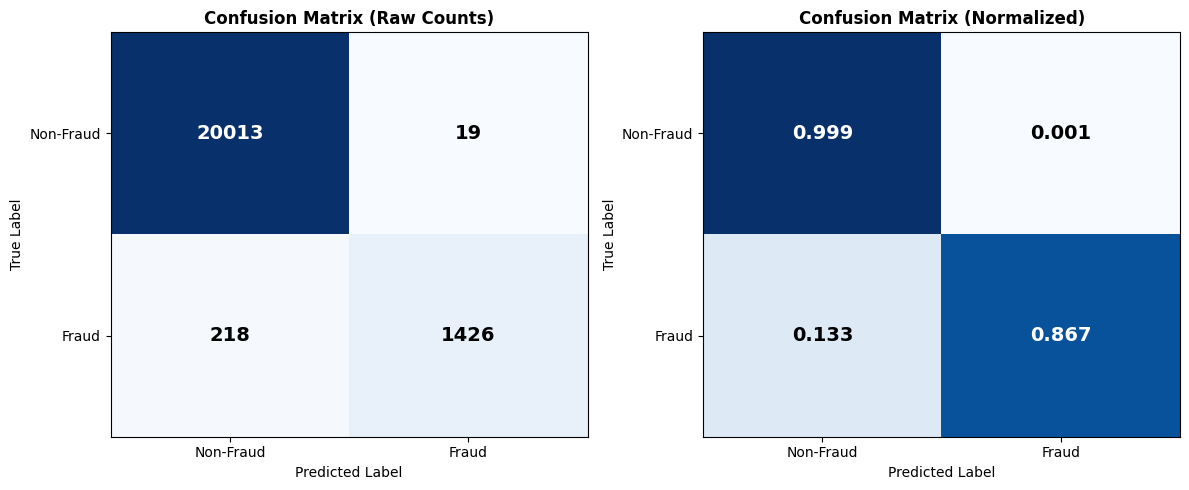

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Raw confusion matrix
axes[0].imshow(confusion_mat, cmap='Blues', aspect='auto')
axes[0].set_title('Confusion Matrix (Raw Counts)', fontsize=12, fontweight='bold')
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Non-Fraud', 'Fraud'])
axes[0].set_yticklabels(['Non-Fraud', 'Fraud'])
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

for i in range(2):
    for j in range(2):
        text_color = 'white' if confusion_mat[i, j] > confusion_mat.max() / 2 else 'black'
        axes[0].text(j, i, f'{confusion_mat[i, j]}',
                    ha='center', va='center',
                    color=text_color, fontsize=14, fontweight='bold')

# Normalized confusion matrix
axes[1].imshow(confusion_mat_normalized, cmap='Blues', aspect='auto')
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=12, fontweight='bold')
axes[1].set_xticks([0, 1])
axes[1].set_yticks([0, 1])
axes[1].set_xticklabels(['Non-Fraud', 'Fraud'])
axes[1].set_yticklabels(['Non-Fraud', 'Fraud'])
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

for i in range(2):
    for j in range(2):
        text_color = 'white' if confusion_mat_normalized[i, j] > 0.5 else 'black'
        axes[1].text(j, i, f'{confusion_mat_normalized[i, j]:.3f}',
                    ha='center', va='center',
                    color=text_color, fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### Training History Visualization

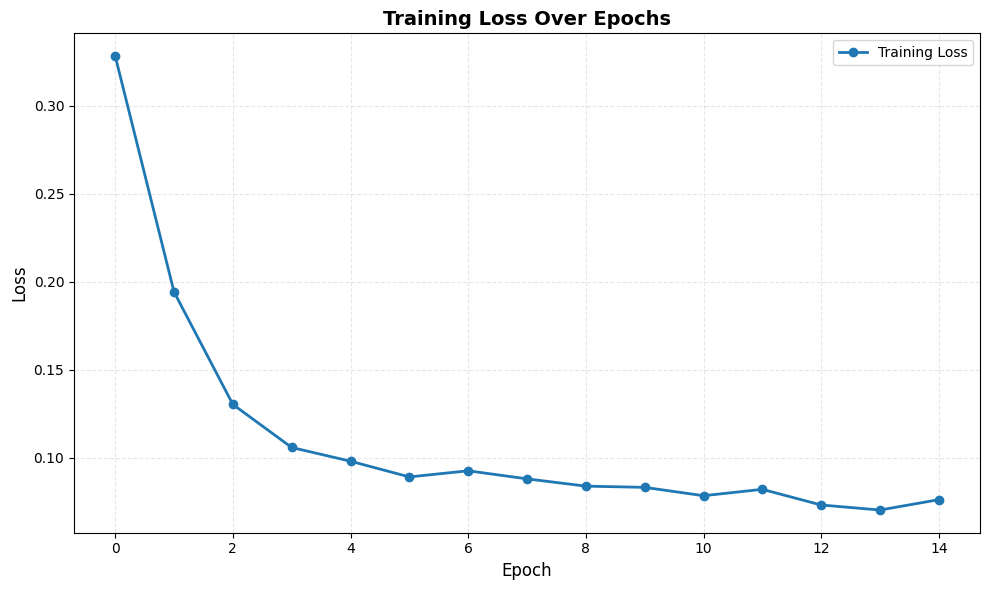

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(training_history['train_loss'], marker='o', linewidth=2, label='Training Loss')
plt.title('Training Loss Over Epochs', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

### Save Best Model

In [ ]:
MODEL_SAVE_PATH = 'gru_fraud_detector_best.pth'

# Save model state
torch.save({
    'model_state_dict': fraud_detection_model.state_dict(),
    'model_config': {
        'num_transaction_types': NUM_TRANSACTION_TYPES,
        'embedding_dim': 8,
        'lstm_hidden_size': 64,
        'num_lstm_layers': 2,
        'dropout_rate': 0.3
    },
    'threshold': decision_threshold,
    'training_history': training_history,
    'test_metrics': {
        'roc_auc': test_roc_auc,
        'pr_auc': test_pr_auc,
        'recall': test_recall,
        'fpr': test_fpr,
        'precision': test_precision
    }
}, MODEL_SAVE_PATH)

print(f"\nModel saved successfully to: {MODEL_SAVE_PATH}")


Model saved successfully to: lstm_fraud_detector_best.pth
